#  Predizione del Costo della Polizza Assicurativa Sanitaria, di Cristiano De Luca


**Dataset:** [Kaggle - Insurance Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance/data)

In questo progetto cercheremo di costruire un modello di **regressione** capace di stimare il costo di una polizza sanitaria a partire dalle caratteristiche personali di un individuo.

Le variabili disponibili nel dataset sono:
- `age`: età della persona
- `sex`: sesso (male/female)
- `bmi`: indice di massa corporea
- `children`: numero di figli
- `smoker`: fumatore (yes/no)
- `region`: regione geografica
- `charges`: **variabile target** — costo della polizza assicurativa

Seguiremo questi passaggi:
1. Importazione librerie e dataset
2. Caricamento dataset
3. Analisi esplorativa (EDA)
4. Pre-Processing
5. Addestramento dei modelli
6. Confronto tra modelli
7. Approfondimento modelli
8. Conclusioni


---
## 1.  Importazione delle Librerie

Per prima cosa importiamo tutte le librerie che ci serviranno nel corso del progetto. Le principali sono:
- `pandas` e `numpy` per manipolare i dati
- `matplotlib` e `seaborn` per i grafici
- `scikit-learn` per i modelli di machine learning


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelli di regressione
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Pre-processing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Per ignorare warning non critici
import warnings
warnings.filterwarnings('ignore')

# Stile dei grafici
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print(' Librerie importate correttamente!')

 Librerie importate correttamente!


---
## 2.  Caricamento del Dataset

Carichiamo il dataset. Poi diamo un'occhiata alle prime righe per capire com'è strutturato.

In [ ]:
import io
df = pd.read_csv('/content/insurance.csv')
#diamo un occhiata alle prime 10 righe
print("Prime 10 righe del dataset:")
display(df.head(10))

Prime 10 righe del dataset:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
# Informazioni generali sul dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# Statistiche descrittive delle variabili numeriche
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


---
## 3. Analisi Esplorativa dei Dati (EDA)

Prima di costruire qualsiasi modello è fondamentale capire i dati. Guardiamo:
- Se ci sono valori mancanti
- La distribuzione delle variabili
- Le relazioni tra le variabili e il target (`charges`)


In [ ]:
# Controllo valori mancanti
print('Valori mancanti per colonna:')
print(df.isnull().sum())
print(f'\nNessun valore mancante: {df.isnull().sum().sum() == 0}')

Valori mancanti per colonna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Nessun valore mancante: True


### 3.1 Distribuzione della variabile target `charges`

Vediamo com'è distribuito il costo della polizza. Se la distribuzione è molto asimmetrica, potrebbe essere utile applicare una trasformazione logaritmica.

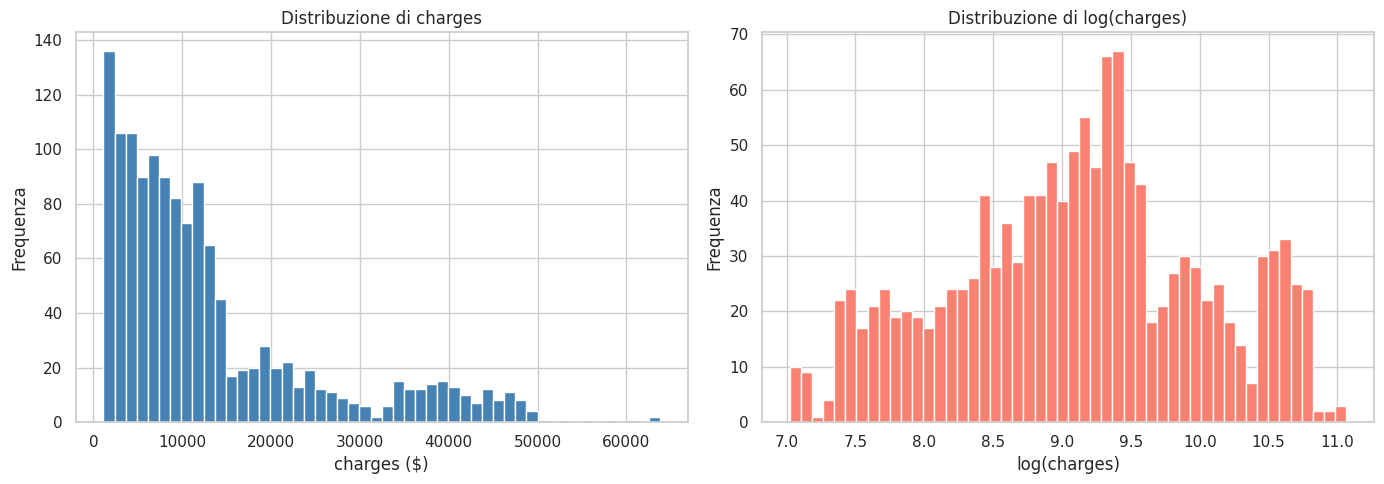

Skewness originale: 1.516
Skewness log-trasformata: -0.090


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuzione originale
axes[0].hist(df['charges'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuzione di charges')
axes[0].set_xlabel('charges ($)')
axes[0].set_ylabel('Frequenza')

# Distribuzione log-trasformata
axes[1].hist(np.log(df['charges']), bins=50, color='salmon', edgecolor='white')
axes[1].set_title('Distribuzione di log(charges)')
axes[1].set_xlabel('log(charges)')
axes[1].set_ylabel('Frequenza')

plt.tight_layout()
plt.show()

print(f'Skewness originale: {df["charges"].skew():.3f}')
print(f'Skewness log-trasformata: {np.log(df["charges"]).skew():.3f}')

### 3.2 Istogrammi delle variabili numeriche

Visualizziamo la distribuzione di tutte le variabili numeriche del dataset.

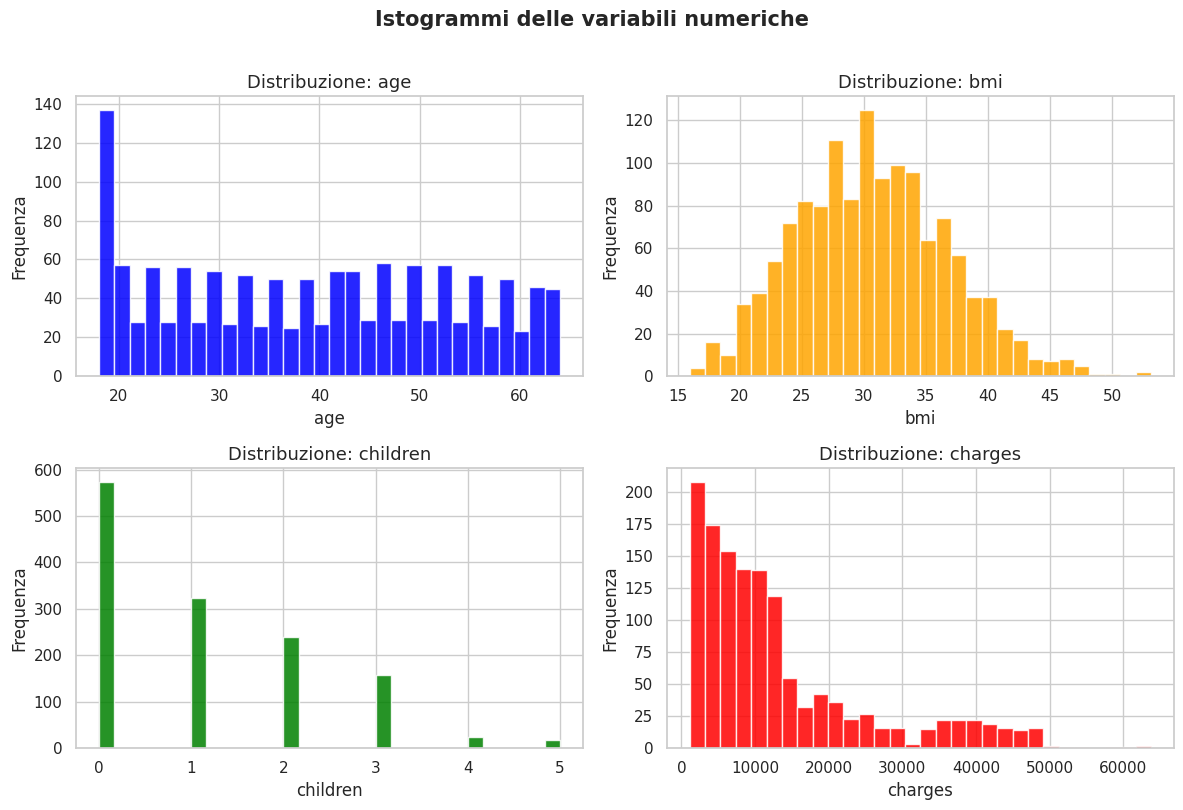

In [ ]:
colonne_numeriche = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()


colors = ['Blue', 'Orange', 'Green', 'Red']

for i, col in enumerate(colonne_numeriche):
    axes[i].hist(df[col], bins=30, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribuzione: {col}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequenza')

plt.suptitle('Istogrammi delle variabili numeriche', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Variabili categoriche

Ora visualizziamo le variabili categoriche (`sex`, `smoker`, `region`) per capire la distribuzione delle categorie.

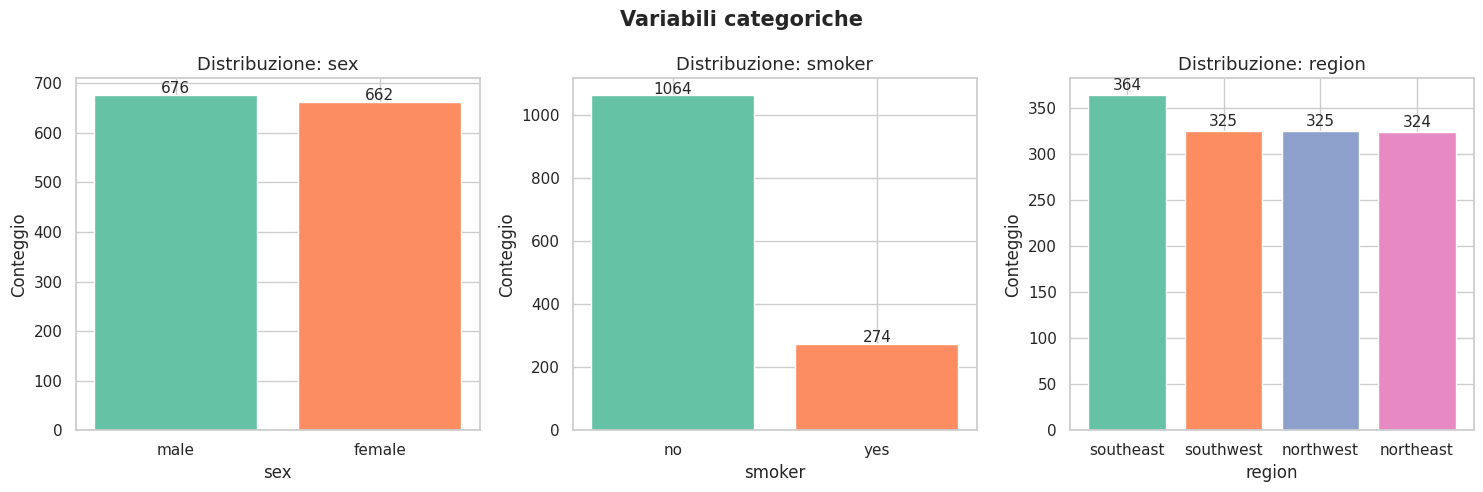

In [ ]:
colonne_categorighe = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(colonne_categorighe):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)), edgecolor='white')
    axes[i].set_title(f'Distribuzione: {col}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Conteggio')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha='center', fontsize=11)

plt.suptitle('Variabili categoriche', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Relazione tra le variabili e `charges`

Vediamo come le diverse variabili influenzano il costo della polizza. Il grafico scatter BMI vs charges mostra chiaramente che i fumatori tendono ad avere costi molto più alti.

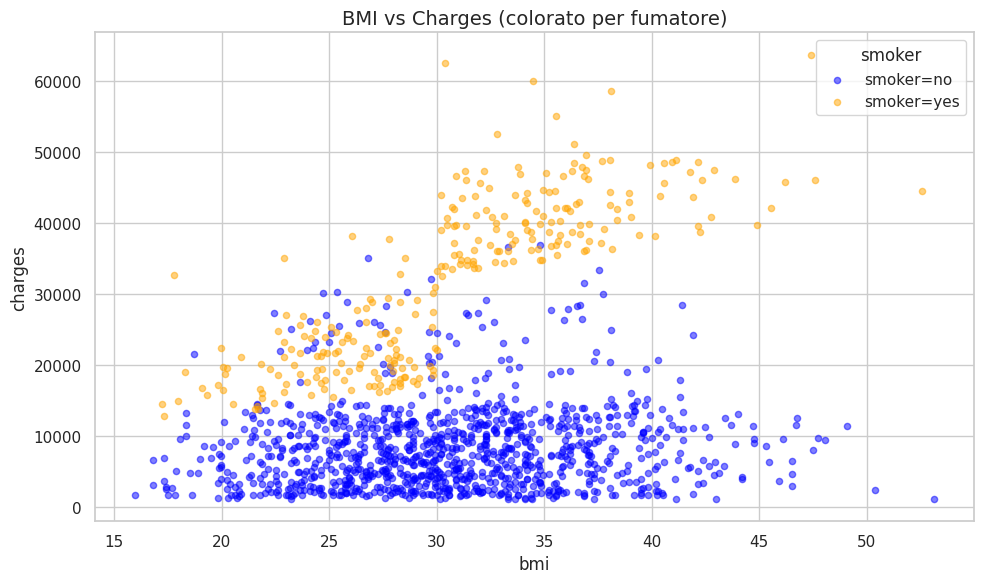

In [ ]:
# Scatter BMI vs Charges, colorato per fumatore (come nella slide)
plt.figure(figsize=(10, 6))
colors_smoke = {'yes': 'orange', 'no': 'blue'}
for smoker_val, group in df.groupby('smoker'):
    plt.scatter(group['bmi'], group['charges'], label=f'smoker={smoker_val}',
                alpha=0.5, s=20, color=colors_smoke[smoker_val])

plt.title('BMI vs Charges (colorato per fumatore)', fontsize=14)
plt.xlabel('bmi')
plt.ylabel('charges')
plt.legend(title='smoker')
plt.tight_layout()
plt.show()

#BoxPlot
Il boxplot è un grafico che riassume una variabile numerica in modo molto compatto: ti fa vedere mediana, quartili, dispersione e possibili outlier.

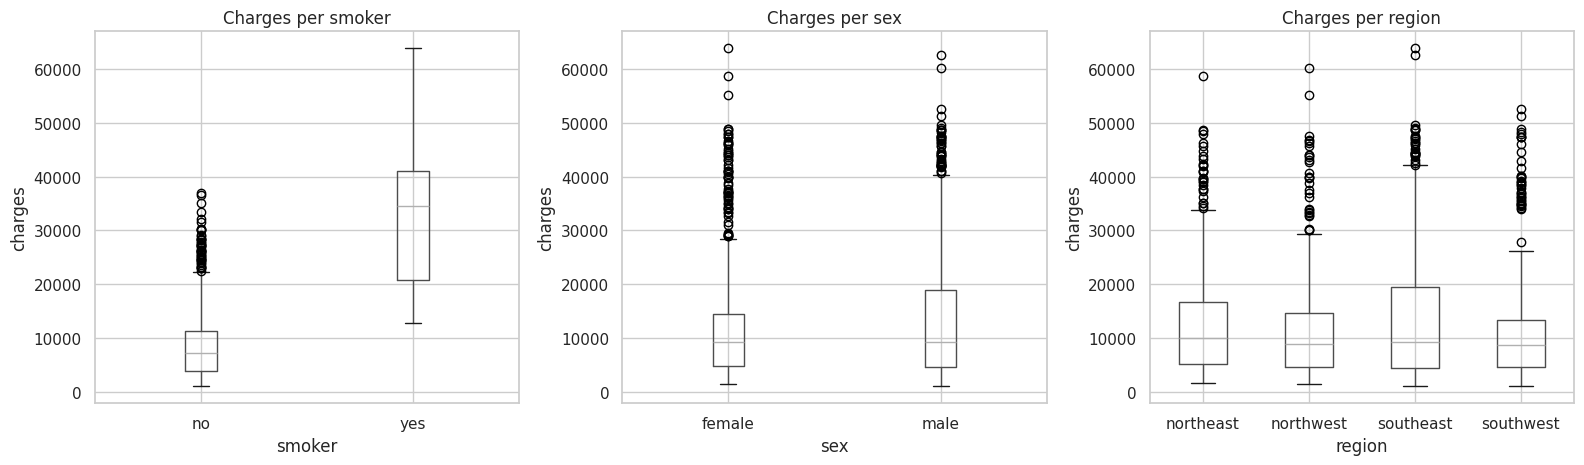

In [ ]:
# Boxplot: charges per fumatori vs non fumatori
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['smoker', 'sex', 'region']):
    df.boxplot(column='charges', by=col, ax=axes[i])
    axes[i].set_title(f'Charges per {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('charges')

plt.suptitle('')
plt.tight_layout()
plt.show()

---
## 4.  Pre-processing

I modelli di machine learning lavorano con numeri, quindi dobbiamo:
1. **Codificare** le variabili categoriche (sex, smoker, region) in numeri
2. **Scalare** le variabili numeriche (utile per la regressione lineare)
3. **Dividere** il dataset in training set e test set


In [ ]:
# Copia del dataframe originale
df_model = df.copy()

# One-Hot Encoding per le variabili categoriche
df_model = pd.get_dummies(df_model, columns=['sex', 'smoker', 'region'], drop_first=True)

print('Colonne dopo encoding:')
print(df_model.columns.tolist())
df_model.head()

Colonne dopo encoding:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [ ]:
# Separazione features (X) e target (y)
X = df_model.drop('charges', axis=1)
y = df_model['charges']

# Split train / test (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} campioni')
print(f'Test set: {X_test.shape[0]} campioni')

Training set: 1070 campioni
Test set: 268 campioni


 #SCALING

 passaggio in cui porti le variabili numeriche su una scala più comparabile, così una feature con valori grandi non domina solo perché ha numeri più alti. Nel tuo progetto serve soprattutto per rendere più adatto il dataset a modelli come la regressione lineare, che beneficiano di input più omogenei

In [ ]:
# Scaling delle feature (utile per modelli lineari)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(' Pre-processing completato!')

 Pre-processing completato!


---
## 5. Addestramento dei Modelli

Proviamo 2 modelli: Regressore Lineare e random forest
1. **Linear Regression** — modello base
5. **Random Forest Regressor** — insieme di alberi decisionali

Per ogni modello calcoleremo:
- **MAE** (Mean Absolute Error): errore medio assoluto
- **RMSE** (Root Mean Squared Error): radice dell'errore quadratico medio
- **R²** (R-squared): coefficiente di determinazione (1 = perfetto)

questi tre indici servono a capire quanto bene il modello stima il costo della polizza.

Se il MAE è basso, vuol dire che in media il modello sbaglia poco nel prevedere il costo. Se il RMSE è basso, vuol dire che anche gli errori grandi sono contenuti. Se il R² è alto, vuol dire che il modello riesce a spiegare bene le differenze tra i costi delle varie persone.

#Differenza addestramenti

il linear regressor: modello cerca la retta o iperpiano che approssima meglio charges usando età, BMI, figli e le variabili codificate.

 il random forest usa un insieme di alberi per essere piu preciso per evitare il problema dell'overfitting

In [ ]:
# Dizionario dei modelli - include solo Regressione Lineare e Random Forest
models = {
    'Linear Regression':    LinearRegression(),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42)
}

# Funzione per valutare un modello
def valuta_modello(nome, modello, X_tr, X_te, y_tr, y_te):
    modello.fit(X_tr, y_tr)
    y_pred = modello.predict(X_te)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    return {'Modello': nome, 'MAE': round(mae,2), 'RMSE': round(rmse,2), 'R²': round(r2,4)}

risultati = []

for nome, mod in models.items():
    # Modelli lineari usano dati scalati; alberi no
    if 'Regression' in nome:
        res = valuta_modello(nome, mod, X_train_scaled, X_test_scaled, y_train, y_test)
    else:
        res = valuta_modello(nome, mod, X_train, X_test, y_train, y_test)
    risultati.append(res)
    print(f'{nome:25s} → MAE: {res["MAE"]:>10.2f}  |  RMSE: {res["RMSE"]:>10.2f}  |  R²: {res["R²"]:.4f}')

df_risultati = pd.DataFrame(risultati)
print('\n Addestramento completato!')

Linear Regression         → MAE:    4181.19  |  RMSE:    5796.28  |  R²: 0.7836
Random Forest             → MAE:    2550.08  |  RMSE:    4576.30  |  R²: 0.8651

 Addestramento completato!


---
## 6.  Confronto dei Modelli

Mettiamo a confronto tutti i modelli in modo visivo per capire qual è il migliore.


In [ ]:
# Tabella riepilogativa
print(' Tabella di confronto dei modelli:')
df_risultati.sort_values('R²', ascending=False).reset_index(drop=True)

 Tabella di confronto dei modelli:


,Modello,MAE,RMSE,R²
0,Random Forest,2550.08,4576.30,0.8651
1,Linear Regression,4181.19,5796.28,0.7836


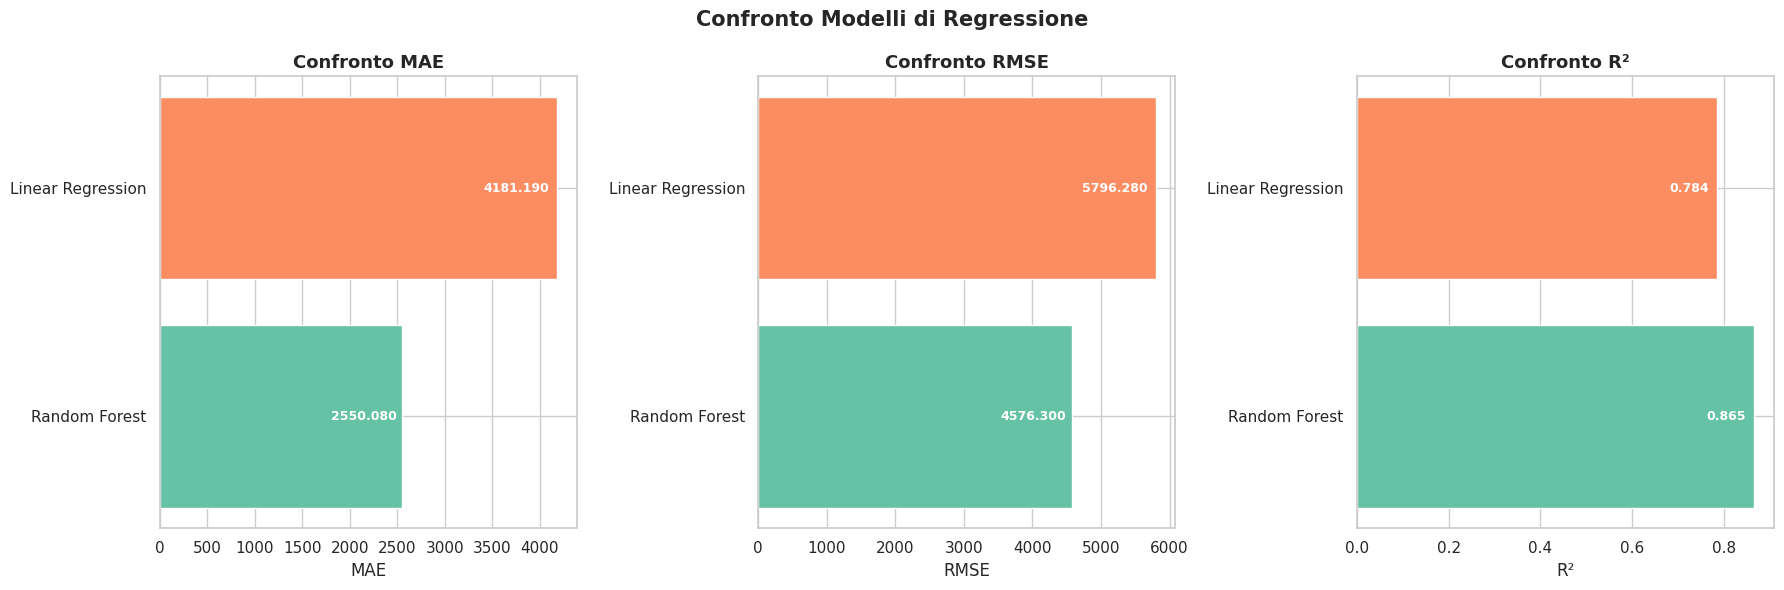

In [ ]:
# Grafici a barre per il confronto
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Filtra df_risultati per includere solo Linear Regression e Random Forest
df_risultati_filtered = df_risultati[df_risultati['Modello'].isin(['Linear Regression', 'Random Forest'])]

palette = sns.color_palette('Set2', len(df_risultati_filtered))
metriche = ['MAE', 'RMSE', 'R²']

for i, metrica in enumerate(metriche):
    df_sorted = df_risultati_filtered.sort_values(metrica, ascending=(metrica != 'R²'))
    axes[i].barh(df_sorted['Modello'], df_sorted[metrica], color=palette)
    axes[i].set_title(f'Confronto {metrica}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(metrica)
    for j, val in enumerate(df_sorted[metrica]):
        axes[i].text(val * 0.98, j, f'{val:.3f}', va='center', ha='right', fontsize=9, color='white', fontweight='bold')

plt.suptitle('Confronto Modelli di Regressione', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.1 Valori Reali vs Predetti

Un grafico molto utile per valutare visivamente un modello di regressione è il **scatter plot predicted vs actual**: se il modello fosse perfetto, tutti i punti cadrebbero sulla retta diagonale.

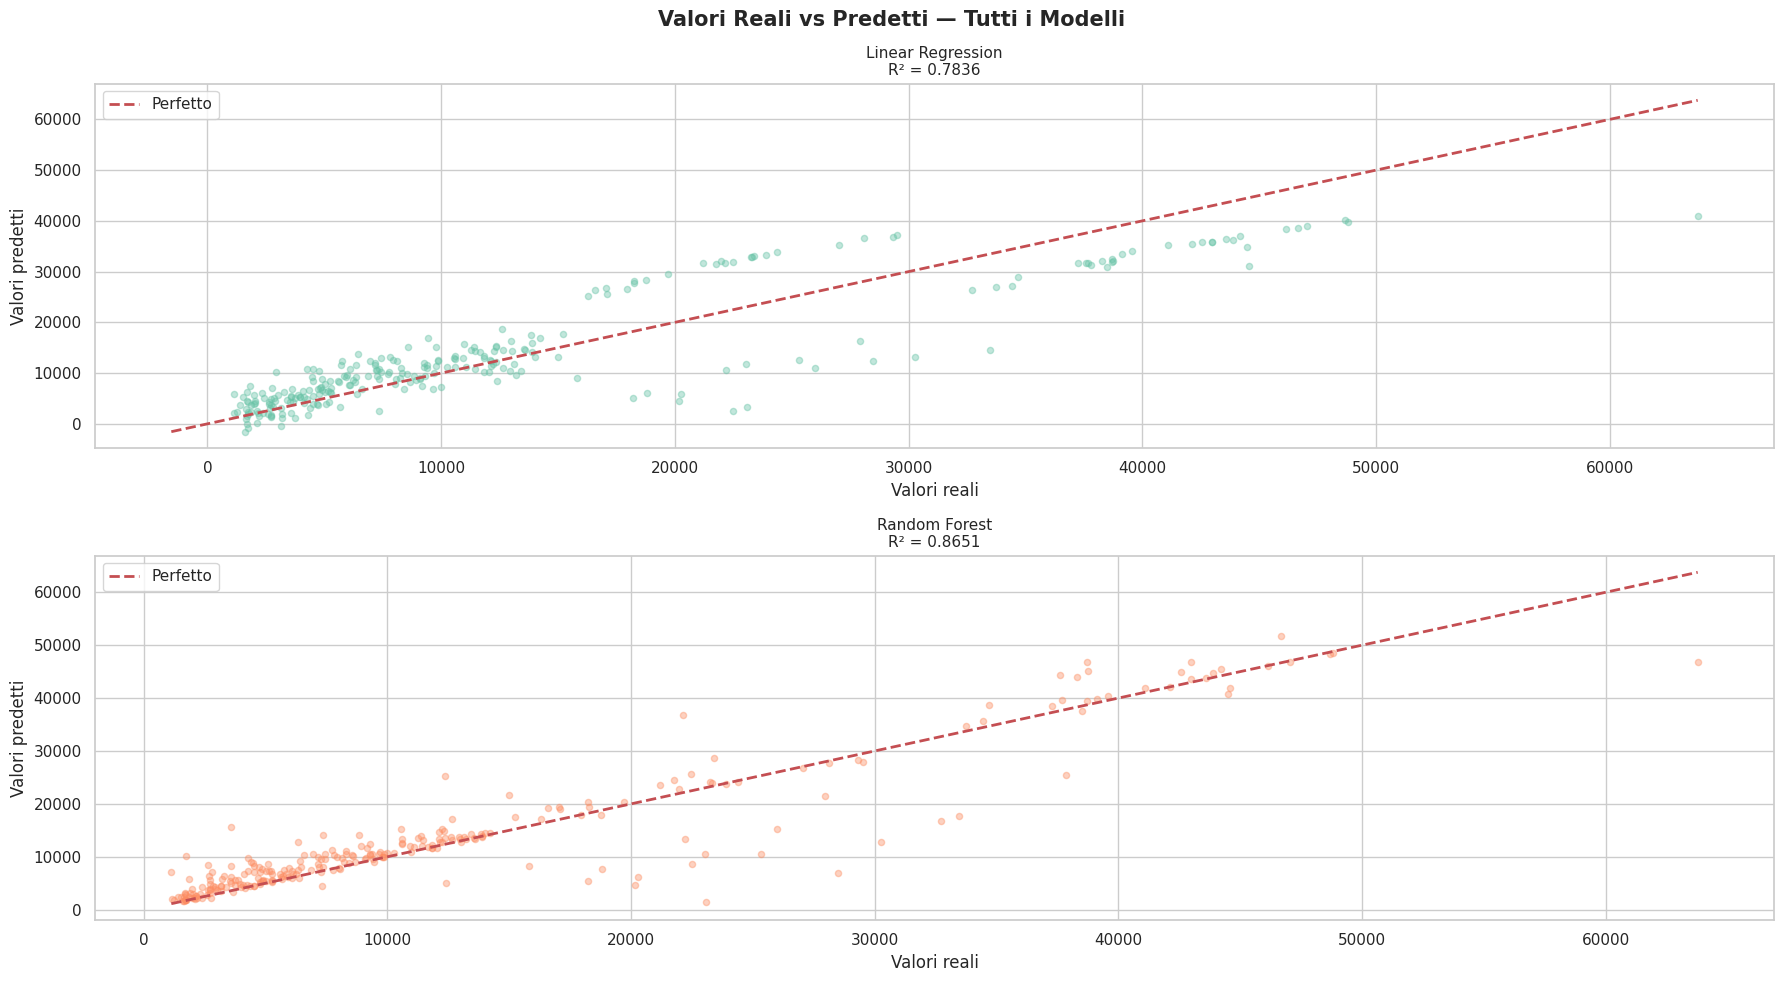

In [ ]:
fig, axes = plt.subplots(2, figsize=(18, 10))
axes = axes.flatten()

# Ri-addestriamo i modelli per ottenere le predizioni (potrebbero essere già salvate)
models_riaddestrati = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42)
}

colori = sns.color_palette('Set2', 5)

for idx, (nome, mod) in enumerate(models_riaddestrati.items()):
    if 'Regression' in nome:
        mod.fit(X_train_scaled, y_train)
        y_pred = mod.predict(X_test_scaled)
    else:
        mod.fit(X_train, y_train)
        y_pred = mod.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    axes[idx].scatter(y_test, y_pred, alpha=0.4, color=colori[idx], s=20)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfetto')
    axes[idx].set_title(f'{nome}\nR² = {r2:.4f}', fontsize=11)
    axes[idx].set_xlabel('Valori reali')
    axes[idx].set_ylabel('Valori predetti')
    axes[idx].legend()

plt.suptitle('Valori Reali vs Predetti — Tutti i Modelli', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Distribuzione dei Residui

I residui sono la differenza tra valore reale e valore predetto. Idealmente dovrebbero essere distribuiti come una gaussiana centrata in zero (questo indica che il modello non ha bias sistematici).

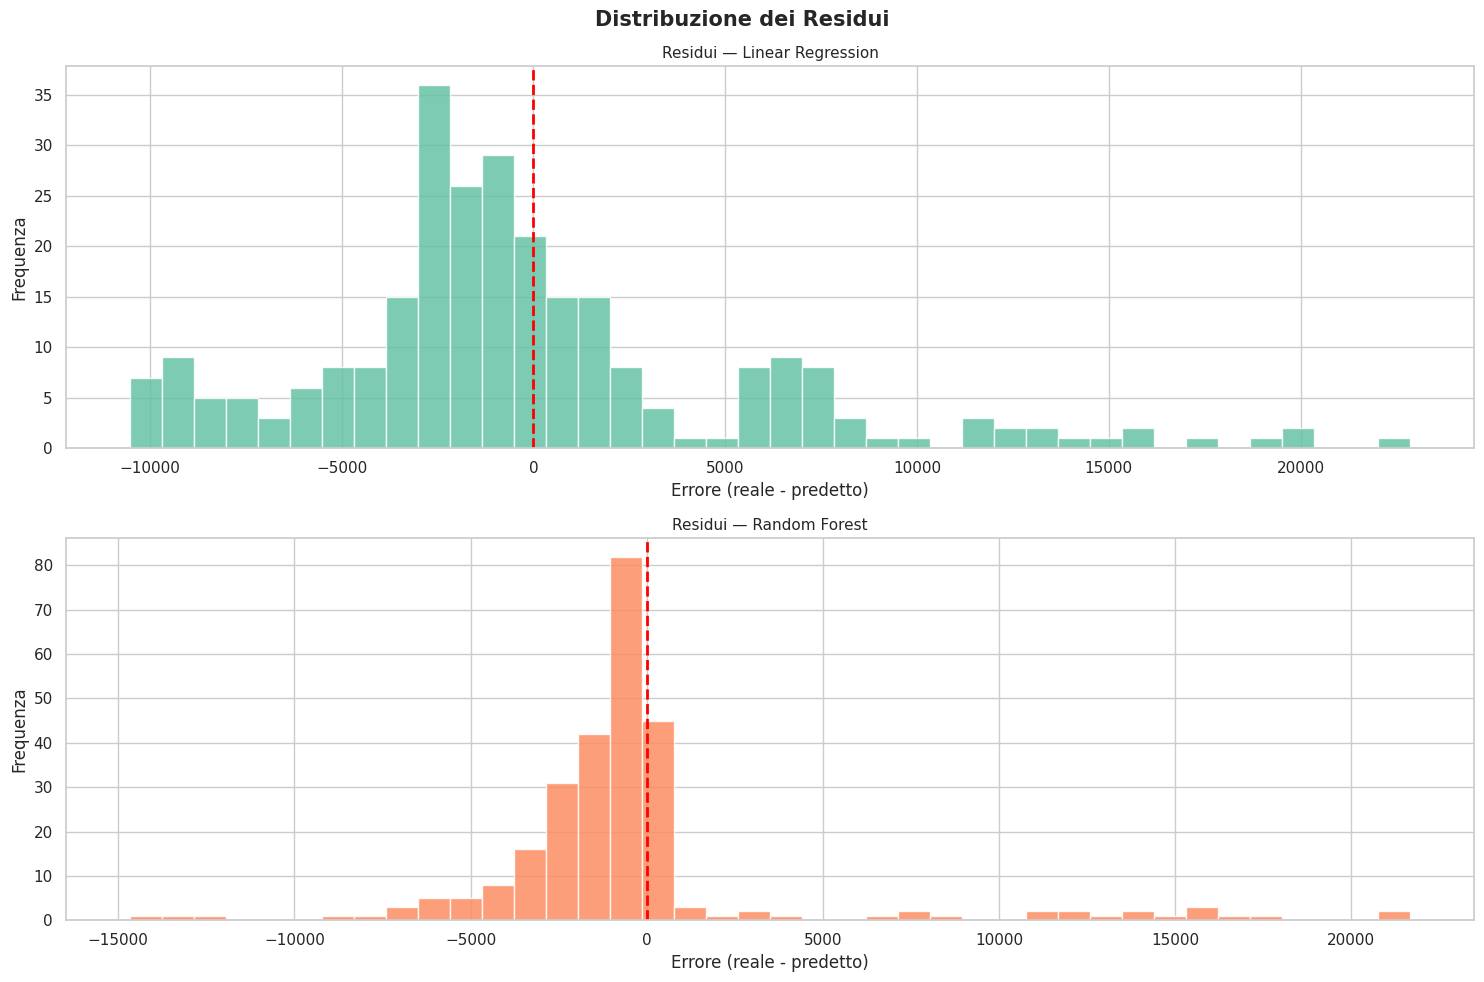

In [ ]:
fig, axes = plt.subplots(2, figsize=(15, 10))
axes = axes.flatten()

for idx, (nome, mod) in enumerate(models_riaddestrati.items()):
    if 'Regression' in nome:
        y_pred = mod.predict(X_test_scaled)
    else:
        y_pred = mod.predict(X_test)

    residui = y_test - y_pred
    axes[idx].hist(residui, bins=40, color=colori[idx], edgecolor='white', alpha=0.85)
    axes[idx].axvline(0, color='red', linestyle='--', lw=2)
    axes[idx].set_title(f'Residui — {nome}', fontsize=11)
    axes[idx].set_xlabel('Errore (reale - predetto)')
    axes[idx].set_ylabel('Frequenza')

#
plt.suptitle('Distribuzione dei Residui', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7.  Feature Importance (Random Forest)

Il Random Forest ci permette di capire quali variabili sono le più importanti per la predizione. Questo è molto utile per interpretare il modello

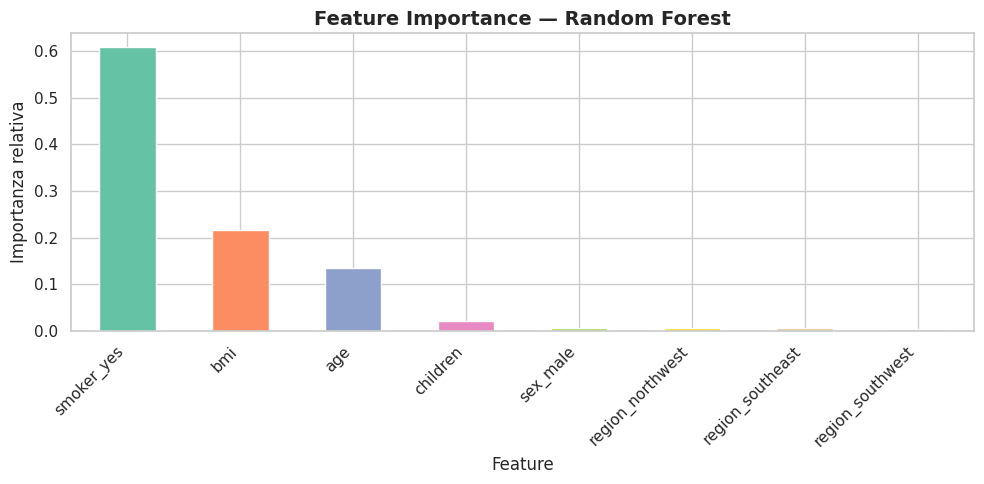

 La variabile più importante è: smoker_yes


In [ ]:
# Recupera il Random Forest già addestrato
rf_model = models_riaddestrati['Random Forest']

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color=sns.color_palette('Set2', len(importances)))
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importanza relativa')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(' La variabile più importante è:', importances.idxmax())

### 7.1 Approfondimento: Linear Regression e Random forest

In questa sezione isoliamo il comportamento dei 2 modelli per analizzarne le predizioni sulla variabile target `charges`.

In [ ]:
# Inizializzazione e addestramento del modello
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Predizione sui dati di test
y_pred_lin = lin_reg.predict(X_test_scaled)

# Calcolo delle metriche
mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print(f'--- Risultati Linear Regression ---')
print(f'MAE:  {mae_lin:.2f}')
print(f'RMSE: {rmse_lin:.2f}')
print(f'R²:   {r2_lin:.4f}')

# Visualizzazione prime 5 predizioni vs valori reali
confronto = pd.DataFrame({'Reale': y_test, 'Predetto': y_pred_lin}).head()
display(confronto)



--- Risultati Linear Regression ---
MAE:  4181.19
RMSE: 5796.28
R²:   0.7836


,Reale,Predetto
764,9095.06825,8969.550274
887,5272.17580,7068.747443
890,29330.98315,36858.410912
1293,9301.89355,9454.678501
259,33750.29180,26973.173457


---
## 8.  Conclusioni

### Riepilogo dei risultati

In [ ]:

# Ordinamento e visualizzazione della classifica finale
df_risultati_sorted = df_risultati.sort_values('R²', ascending=False).reset_index(drop=True)
df_risultati_sorted.index += 1

print(' Classifica finale dei modelli (per R²):')
display(df_risultati_sorted)


 Classifica finale dei modelli (per R²):


,Modello,MAE,RMSE,R²
1,Random Forest,2550.08,4576.30,0.8651
2,Linear Regression,4181.19,5796.28,0.7836


### Considerazioni finali

Da questa analisi abbiamo imparato che:

1. **Il fumo è la variabile più influente**: i fumatori hanno costi assicurativi molto più elevati rispetto ai non fumatori.

2. **Il regressore lineare** (Linear) ha performance che potrebbero soffrire della non-linearità del dataset.

3. **Il Random Forest** è generalmente il modello con il migliore R², grazie alla sua capacità di catturare relazioni non lineari tra le variabili.


